# Taller de POO: Gestión y Análisis de Datos de Ventas

El objetivo es construir un pipeline de datos robusto utilizando los pilares de la POO: Abstracción, Herencia y Encapsulamiento.

## Documentación: Uso de Herencia vs. Mixins

En este diseño arquitectónico, hemos diferenciado entre **Herencia Clásica** y **Mixins** por las siguientes razones:

1. **Herencia Clásica (`DataComponent`):** 
   Se utiliza para definir la identidad principal del objeto ("es un"). Establece un **contrato estricto** (a través de `ABC` y `@abstractmethod`) que obliga a las subclases a implementar el método `execute()`. Esto garantiza polimorfismo, asegurando que el flujo principal trate a `DataLoader` o `DataCleaner` de la misma manera estructural.

2. **Mixins (`LoggerMixin`, `ValidatorMixin`):**
   Se emplean para proveer habilidades adicionales o funcionalidades transversales ("sabe hacer") sin forzar una jerarquía rígida. Si pusiéramos la lógica de validación o logs dentro de `DataComponent`, obligaríamos a todos los componentes a heredarla incluso si no la necesitan, acoplando el código. Los mixins, a través de la herencia múltiple de Python, nos permiten "inyectar" funcionalidades modulares manteniendo un diseño limpio y altamente cohesivo.

## Fase 1: Arquitectura Base y Mixins
Paso 1: Interfaz `DataComponent`.
Paso 2: Herramientas `ValidatorMixin` y `LoggerMixin`.

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod

# Paso 1: Clase abstracta con método obligatorio
class DataComponent(ABC):
    @abstractmethod
    def execute(self):
        pass

# Paso 2: Mixins para funcionalidades transversales
class LoggerMixin:
    def log(self, mensaje):
        print(f"[LOG] {mensaje}")

class ValidatorMixin:
    def validate_file(self, ruta):
        if not os.path.exists(ruta):
            raise FileNotFoundError(f"Archivo no encontrado: '{ruta}'")
        return True

    def validate_columns(self, df, columnas_requeridas):
        faltantes = [c for c in columnas_requeridas if c not in df.columns]
        if faltantes:
            raise ValueError(f"Faltan columnas obligatorias: {faltantes}")
        return True


## Fase 2: Ingesta y Transformación
Paso 3: `DataLoader` con atributo privado `__file_path`.
Paso 4: `DataCleaner` con imputación, tipos y uso de `@property`.

In [6]:
# Paso 3: DataLoader hereda de DataComponent y Mixins
class DataLoader(DataComponent, LoggerMixin, ValidatorMixin):
    def __init__(self, file_path):
        self.__file_path = file_path

    def execute(self):
        self.log(f"Validando archivo: {self.__file_path}")
        self.validate_file(self.__file_path)
        
        self.log("Cargando el archivo CSV...")
        df = pd.read_csv(self.__file_path)
        self.validate_columns(df, ['fecha', 'producto', 'ventas'])
            
        self.log(f"Lectura exitosa. Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
        return df

# Paso 4: DataCleaner (Optimizado, sin redundancia de bucles)
class DataCleaner(DataComponent, LoggerMixin):
    def __init__(self, df):
        self.__df = df.copy()

    def execute(self):
        self.log("Iniciando limpieza de datos de forma vectorizada...")
        df = self.__df
        
        # Optimización: Limpiar todas las numéricas sin bucles 'for'
        num_cols = df.select_dtypes(include=['number']).columns
        if not num_cols.empty:
            df[num_cols] = df[num_cols].fillna(df[num_cols].mean())
            self.log(f"Imputados nulos (media) en numéricas: {list(num_cols)}")

        # Optimización: Limpiar todas las categóricas sin bucles 'for'
        obj_cols = df.select_dtypes(include=['object']).columns
        if not obj_cols.empty:
            df[obj_cols] = df[obj_cols].fillna('desconocido')
            self.log(f"Imputados nulos ('desconocido') en categóricas: {list(obj_cols)}")

        if 'fecha' in df.columns:
            df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
            self.log("Conversión de fecha realizada.")

        return self.__df

    @property
    def resumen_estadistico(self):
        """Uso de @property para exponer resúmenes estadísticos de forma segura."""
        return self.__df.describe(include='all')


## Fase 3: Análisis y Orquestación
Paso 5: `DataAnalyst` (Polimorfismo, descriptivo por consola y gráfico).
Paso 6: El "Main" del Notebook.

In [7]:
# Paso 5: DataAnalyst
class DataAnalyst(DataComponent, LoggerMixin):
    def __init__(self, df):
        self.__df = df

    def reporte_consola(self):
        self.log("Generando reporte descriptivo en consola...")
        print(self.__df.head())
        print("\nTipos de datos:")
        print(self.__df.dtypes)

    def grafico_ventas(self):
        self.log("Generando gráfico de barras por producto...")
        if 'producto' not in self.__df.columns or 'ventas' not in self.__df.columns:
            return
            
        resumen = self.__df.groupby('producto', as_index=False)['ventas'].sum()
        
        plt.figure(figsize=(9, 5))
        sns.barplot(data=resumen, x='producto', y='ventas', color='#3d6acb')
        plt.title('Ventas totales por producto', fontsize=14, fontweight='bold')
        plt.xticks(rotation=35, ha='right')
        plt.ylabel('Ventas ($)')
        plt.xlabel('Producto')
        plt.tight_layout()
        plt.show()

    def execute(self):
        """Uso de polimorfismo llamando métodos internos de visualización."""
        self.reporte_consola()
        self.grafico_ventas()


=== EJECUCIÓN DEL PIPELINE ===
[LOG] Validando archivo: dataset.csv
[LOG] Cargando el archivo CSV...
[LOG] Lectura exitosa. Filas: 25, Columnas: 3
[LOG] Iniciando limpieza de datos de forma vectorizada...
[LOG] Imputados nulos (media) en numéricas: ['ventas']
[LOG] Imputados nulos ('desconocido') en categóricas: ['fecha', 'producto']
[LOG] Conversión de fecha realizada.

--- Resumen Estadístico (@property) ---
                                fecha    producto       ventas
count                              23          25    25.000000
unique                            NaN          11          NaN
top                               NaN  Laptop Pro          NaN
freq                              NaN           3          NaN
mean    2026-07-12 19:49:33.913043456         NaN   282.869565
min               2026-07-01 00:00:00         NaN    25.000000
25%               2026-07-07 12:00:00         NaN    70.000000
50%               2026-07-13 00:00:00         NaN   150.000000
75%               2

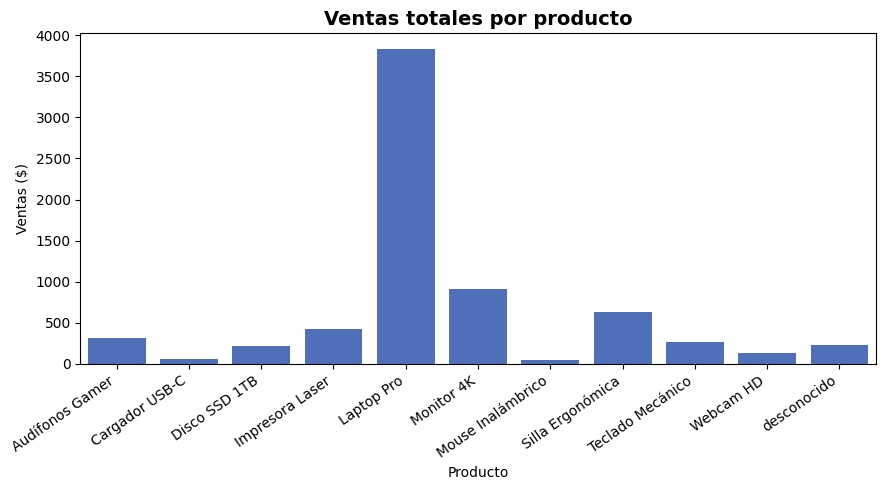


[LOG] Pipeline completado. Datos guardados en ventas_limpias.csv


In [8]:
# Paso 6: Main (Prueba de concepto con dataset real)
print("=== EJECUCIÓN DEL PIPELINE ===")
try:
    # 1. Ingesta
    loader = DataLoader('dataset.csv')
    df_crudo = loader.execute()
    
    # 2. Transformación
    cleaner = DataCleaner(df_crudo)
    df_limpio = cleaner.execute()
    
    print("\n--- Resumen Estadístico (@property) ---")
    print(cleaner.resumen_estadistico)
    
    # 3. Análisis
    print("\n--- Análisis y Gráficos ---")
    analyst = DataAnalyst(df_limpio)
    analyst.execute()
    
    # Guardar resultados
    df_limpio.to_csv('ventas_limpias.csv', index=False)
    print("\n[LOG] Pipeline completado. Datos guardados en ventas_limpias.csv")
    
except Exception as e:
    print(f"\n[ERROR] {e}")
